<a href="https://colab.research.google.com/github/VishnuVardhan320/DataAnalytics_practice/blob/main/DataAnalytics_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#swiggy/ Zomato food delivery analysis
#data
import pandas as pd
data=pd.DataFrame({
    'order_time':[2,5,7,10,8,11,7],#hrs
    'Delivery_time':[3,6,10,12,9,12,9],
    'Delivery_partner':['A','A','B','B','A','B','A'],
    'Rating':[4,5,3,2,4,4,5]
})
print(data)
print(data.info())
#Average delivery time
avg_delivery_time=[]
for i in range(len(data['order_time'])):
    avg_delivery_time.append(data['Delivery_time'][i]-data['order_time'][i])
avg_time=sum(avg_delivery_time)/len(avg_delivery_time)
print(f"Average delivery time : {round(avg_time,2)} hr")
data['de_time']=avg_delivery_time
print(data)
peak_order_time=data['order_time'].value_counts().idxmax()
print(f"Peak order time : {peak_order_time}th hr")
de_p=data.groupby('Delivery_partner')['de_time'].mean()
print(de_p)
top_rate=data.groupby('Delivery_partner')['Rating'].mean()
print(f"top rated patner: {top_rate}")

   order_time  Delivery_time Delivery_partner  Rating
0           2              3                A       4
1           5              6                A       5
2           7             10                B       3
3          10             12                B       2
4           8              9                A       4
5          11             12                B       4
6           7              9                A       5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_time        7 non-null      int64 
 1   Delivery_time     7 non-null      int64 
 2   Delivery_partner  7 non-null      object
 3   Rating            7 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 356.0+ bytes
None
Average delivery time : 1.57 hr
   order_time  Delivery_time Delivery_partner  Rating  de_time
0           2              3         

Delivery_partner
A    4
B    3
Name: order_time, dtype: int64


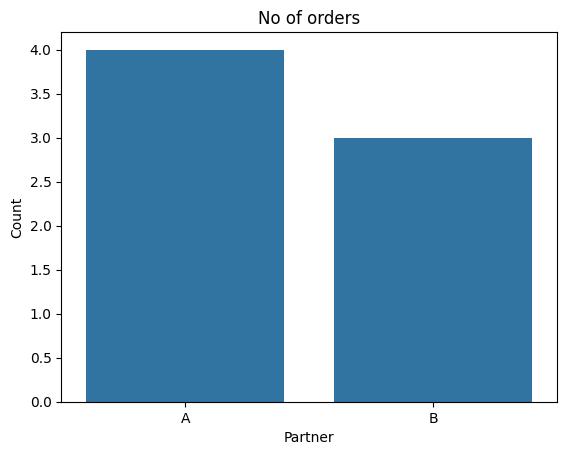

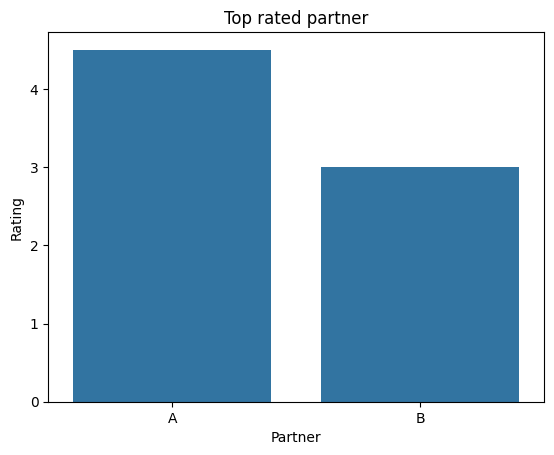

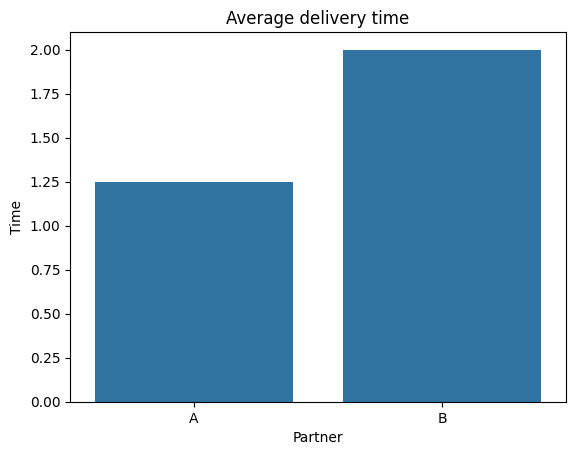

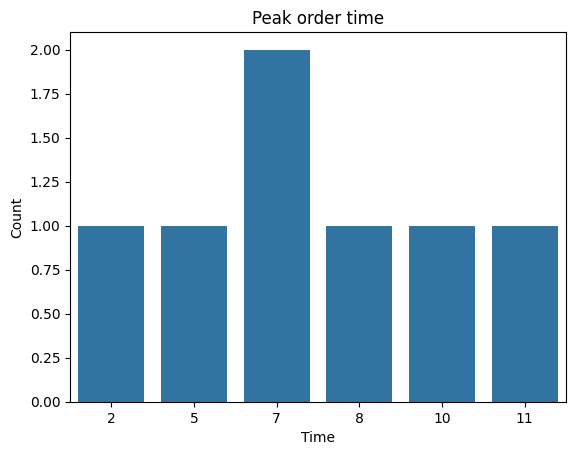

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
no_orders=data.groupby('Delivery_partner')['order_time'].count()
print(no_orders)
sns.barplot(no_orders)
plt.title('No of orders')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.show()
sns.barplot(top_rate)
plt.title('Top rated partner')
plt.xlabel('Partner')
plt.ylabel('Rating')
plt.show()
sns.barplot(de_p)
plt.title('Average delivery time')
plt.xlabel('Partner')
plt.ylabel('Time')
plt.show()
sns.barplot(data['order_time'].value_counts())
plt.title('Peak order time')
plt.xlabel('Time')
plt.ylabel('Count')
plt.show()

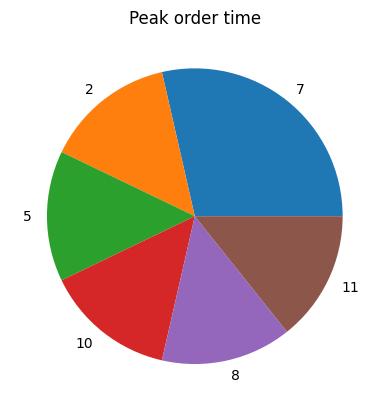

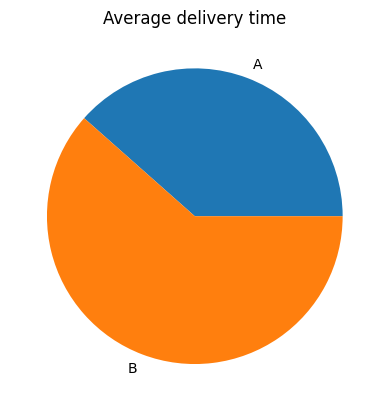

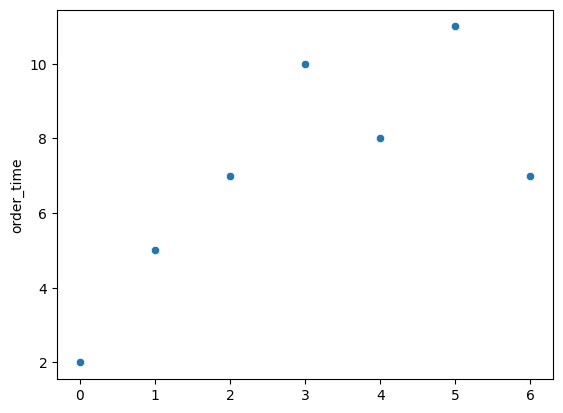

In [ ]:
plt.pie(data['order_time'].value_counts(),labels=data['order_time'].value_counts().index)
plt.title('Peak order time')
plt.show()
plt.pie(data.groupby('Delivery_partner')['de_time'].mean(),labels=data.groupby('Delivery_partner')['de_time'].mean().index)
plt.title('Average delivery time')
plt.show()
sns.scatterplot(data['order_time'])
plt.show()

In [ ]:
#online product purchase
import pandas as pd
data=pd.DataFrame({
    'product_id':[1,2,3,4,5,6,7,8],
    'product_name':['phone','buds','dress','perfume','phone','food','buds','watch'],
    'product_purchases':[10,15,21,19,16,28,12,11],
    'cart_abandoment':[10,15,21,19,16,28,12,11],
    'Customer_rating':[4,5,3,2,4,4,5,3],
    'payment_methods':['UPI','COD','UPI','UPI','UPI','COD','UPI','COD']
})
print(data)
print(data.info())

   product_id product_name  product_purchases  cart_abandoment  \
0           1        phone                 10               10   
1           2         buds                 15               15   
2           3        dress                 21               21   
3           4      perfume                 19               19   
4           5        phone                 16               16   
5           6         food                 28               28   
6           7         buds                 12               12   
7           8        watch                 11               11   

   Customer_rating payment_methods  
0                4             UPI  
1                5             COD  
2                3             UPI  
3                2             UPI  
4                4             UPI  
5                4             COD  
6                5             UPI  
7                3             COD  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data

In [ ]:
# Most sold products
most_sold_products = data.groupby('product_name')['product_purchases'].sum().sort_values(ascending=False)
print(f"\nMost Sold Products:\n{most_sold_products}")
print(f"The product with the highest sales is: {most_sold_products.index[0]} with {most_sold_products.iloc[0]} purchases.")

# Most used payment method
most_used_payment_method = data['payment_methods'].value_counts()
print(f"\nMost Used Payment Method:\n{most_used_payment_method}")
print(f"The most frequently used payment method is: {most_used_payment_method.index[0]} with {most_used_payment_method.iloc[0]} uses.")

# Products with poor rating (e.g., rating less than or equal to 3)
poor_rated_products = data[data['Customer_rating'] <= 3][['product_name', 'Customer_rating']]
print(f"\nProducts with Poor Rating (<= 3):\n{poor_rated_products}")


Most Sold Products:
product_name
food       28
buds       27
phone      26
dress      21
perfume    19
watch      11
Name: product_purchases, dtype: int64
The product with the highest sales is: food with 28 purchases.

Most Used Payment Method:
payment_methods
UPI    5
COD    3
Name: count, dtype: int64
The most frequently used payment method is: UPI with 5 uses.

Products with Poor Rating (<= 3):
  product_name  Customer_rating
2        dress                3
3      perfume                2
7        watch                3


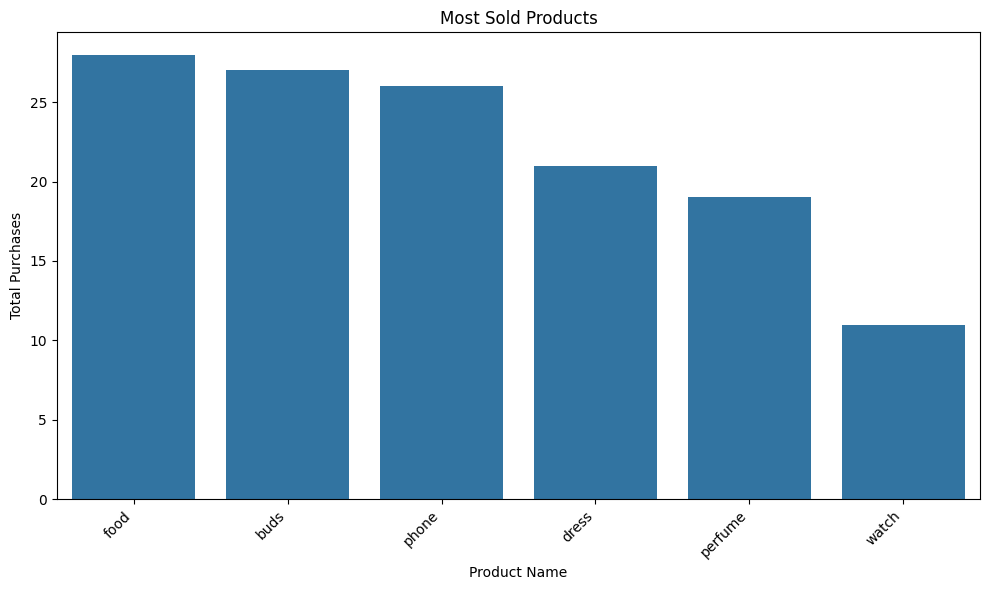

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Most Sold Products
plt.figure(figsize=(10, 6))
sns.barplot(x=most_sold_products.index, y=most_sold_products.values)
plt.title('Most Sold Products')
plt.xlabel('Product Name')
plt.ylabel('Total Purchases')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

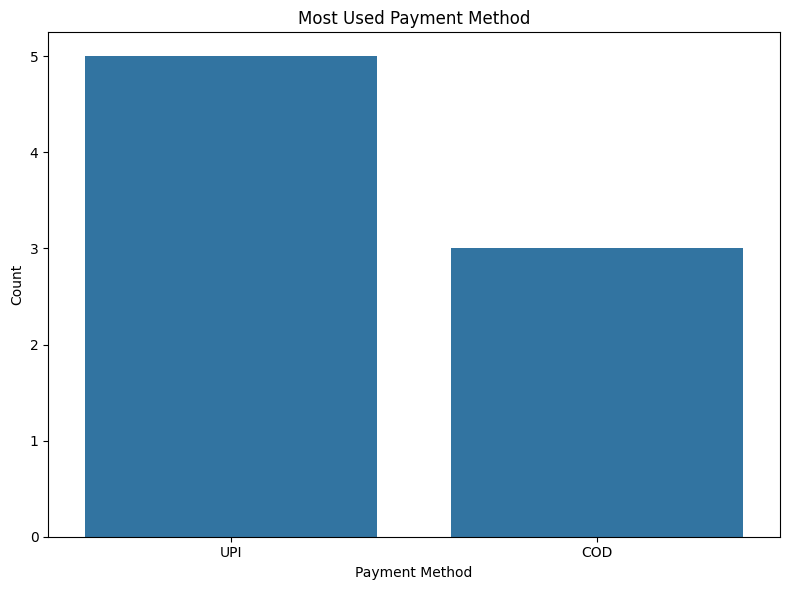

In [ ]:
# Visualize Most Used Payment Method
plt.figure(figsize=(8, 6))
sns.barplot(x=most_used_payment_method.index, y=most_used_payment_method.values)
plt.title('Most Used Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

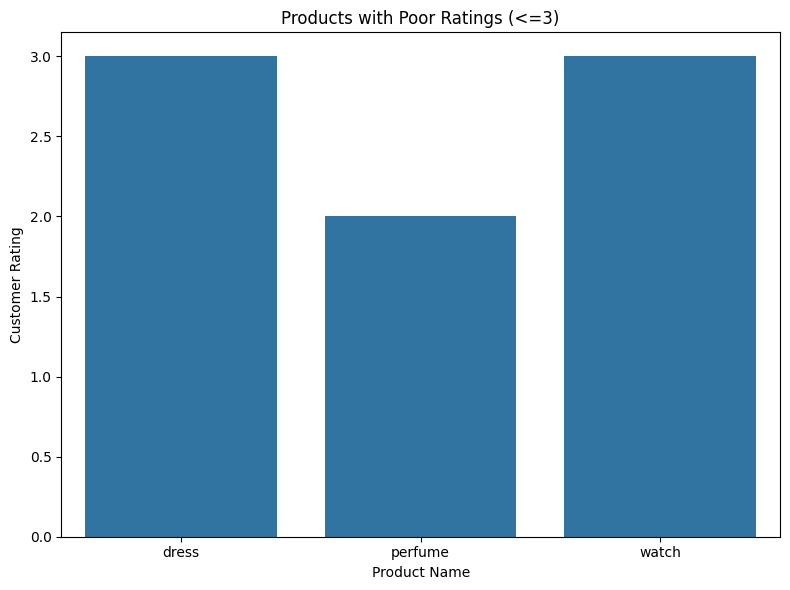

In [ ]:
# Visualize Products with Poor Rating
plt.figure(figsize=(8, 6))
sns.barplot(x=poor_rated_products['product_name'], y=poor_rated_products['Customer_rating'])
plt.title('Products with Poor Ratings (<=3)')
plt.xlabel('Product Name')
plt.ylabel('Customer Rating')
plt.tight_layout()
plt.show()

In [ ]:
#Bank Fraud detection analysis
import pandas as pd
data=pd.DataFrame({
    'transaction_id':[1,2,3,4,5,6,7,8,9,10],
    'amount':[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000],
    'location':['city1','city2','city3','city1','city6','city5','city3','city2','city6','city4'],
    'type':['online','offline','online','offline','online','offline','online','offline','online','offline'],
    'status':['success','failed','success','failed','success','failed','success','failed','success','failed'],
    'time':['10:00','11:00','12:00','13:00','14:00','15:00','16:00','17:00','18:00','19:00'],
    'fraud_score':[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
})

# Convert 'time' column to datetime objects and extract hour
data['time'] = pd.to_datetime(data['time'], format='%H:%M').dt.hour
data = data.rename(columns={'time': 'hour_of_day'})

print(data)
print(data.info())

# 1. Analyze Usual Transactions
print("\n--- Usual Transactions Analysis ---")
# Group by location and type to see average transaction amounts
usual_transactions_summary = data.groupby(['location', 'type'])['amount'].agg(['count', 'mean', 'std']).reset_index()
print("Summary of transactions by location and type:")
print(usual_transactions_summary)

# 2. Identify High-Risk Accounts/Transactions
print("\n--- High-Risk Transactions Analysis ---")
# Define a threshold for high fraud score (e.g., above 0.5)
fraud_threshold = 0.5
high_risk_transactions = data[data['fraud_score'] > fraud_threshold]
print(f"Transactions identified as high-risk (fraud_score > {fraud_threshold}):")
print(high_risk_transactions)

# 3. Analyze Fraud Patterns (based on high-risk transactions)
print("\n--- Fraud Patterns Analysis ---")
if not high_risk_transactions.empty:
    print("Common locations for high-risk transactions:")
    print(high_risk_transactions['location'].value_counts())

    print("\nCommon types for high-risk transactions:")
    print(high_risk_transactions['type'].value_counts())

    print("\nAverage amount for high-risk transactions:")
    print(high_risk_transactions['amount'].mean())

    print("\nStatus of high-risk transactions:")
    print(high_risk_transactions['status'].value_counts())

    print("\nHigh-risk transactions by hour of day:")
    print(high_risk_transactions['hour_of_day'].value_counts().sort_index())
else:
    print("No high-risk transactions found based on the defined threshold.")

   transaction_id  amount location     type   status  hour_of_day  fraud_score
0               1    1000    city1   online  success           10          0.1
1               2    2000    city2  offline   failed           11          0.2
2               3    3000    city3   online  success           12          0.3
3               4    4000    city1  offline   failed           13          0.4
4               5    5000    city6   online  success           14          0.5
5               6    6000    city5  offline   failed           15          0.6
6               7    7000    city3   online  success           16          0.7
7               8    8000    city2  offline   failed           17          0.8
8               9    9000    city6   online  success           18          0.9
9              10   10000    city4  offline   failed           19          1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null 

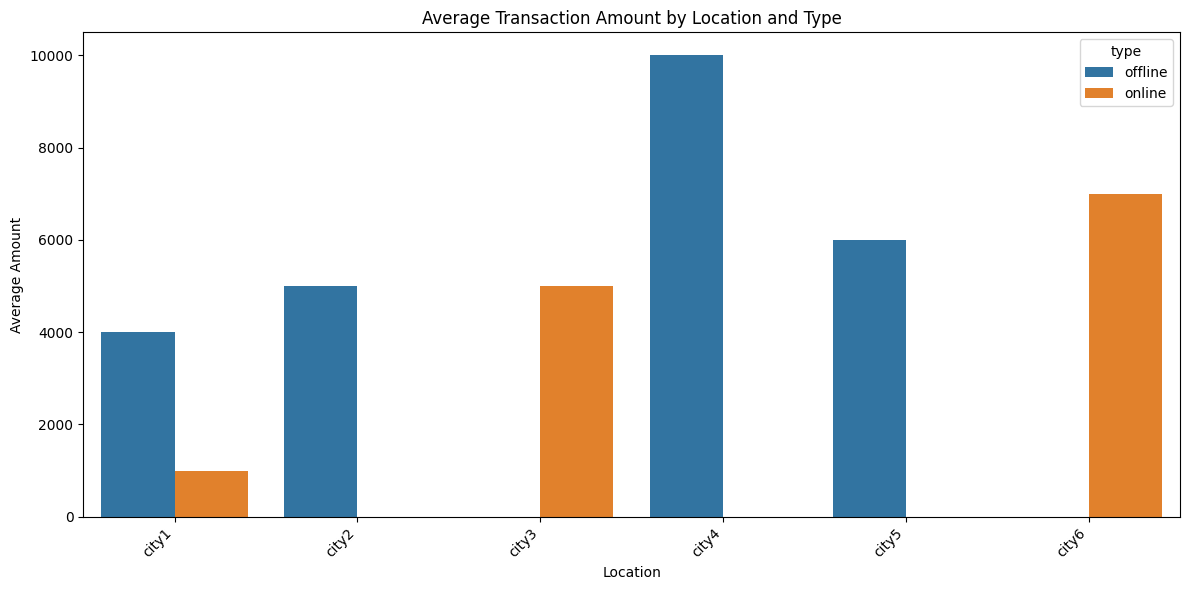

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Average Transaction Amount by Location and Type (Usual Transactions)
plt.figure(figsize=(12, 6))
sns.barplot(x='location', y='mean', hue='type', data=usual_transactions_summary)
plt.title('Average Transaction Amount by Location and Type')
plt.xlabel('Location')
plt.ylabel('Average Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

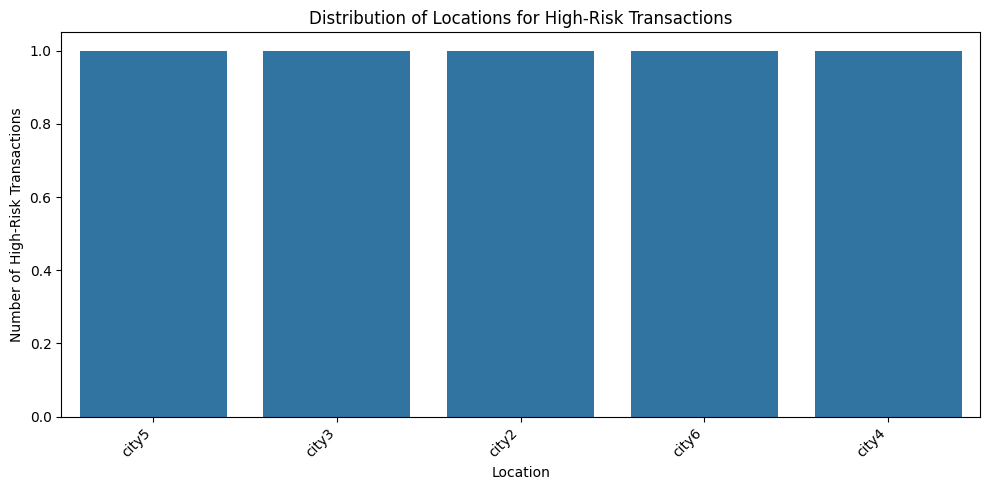

In [ ]:
# Visualize Distribution of High-Risk Transaction Locations
if not high_risk_transactions.empty:
    plt.figure(figsize=(10, 5))
    sns.countplot(x='location', data=high_risk_transactions, order=high_risk_transactions['location'].value_counts().index)
    plt.title('Distribution of Locations for High-Risk Transactions')
    plt.xlabel('Location')
    plt.ylabel('Number of High-Risk Transactions')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No high-risk transactions to visualize locations for.")

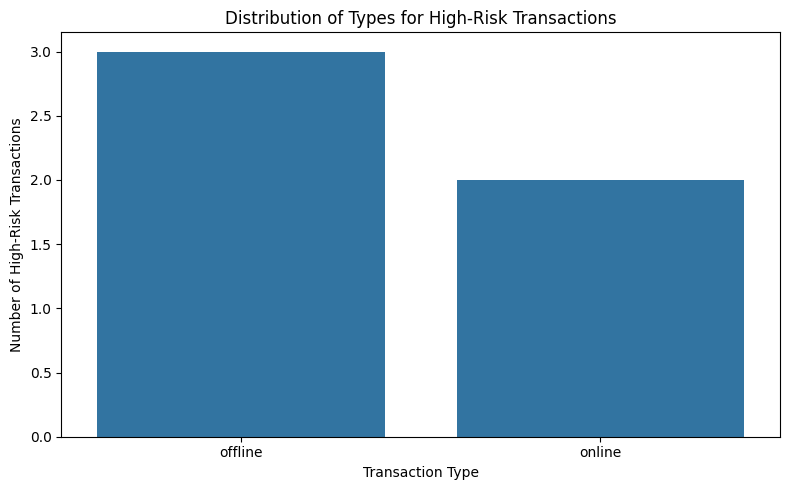

In [ ]:
# Visualize Distribution of High-Risk Transaction Types
if not high_risk_transactions.empty:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='type', data=high_risk_transactions, order=high_risk_transactions['type'].value_counts().index)
    plt.title('Distribution of Types for High-Risk Transactions')
    plt.xlabel('Transaction Type')
    plt.ylabel('Number of High-Risk Transactions')
    plt.tight_layout()
    plt.show()
else:
    print("No high-risk transactions to visualize types for.")

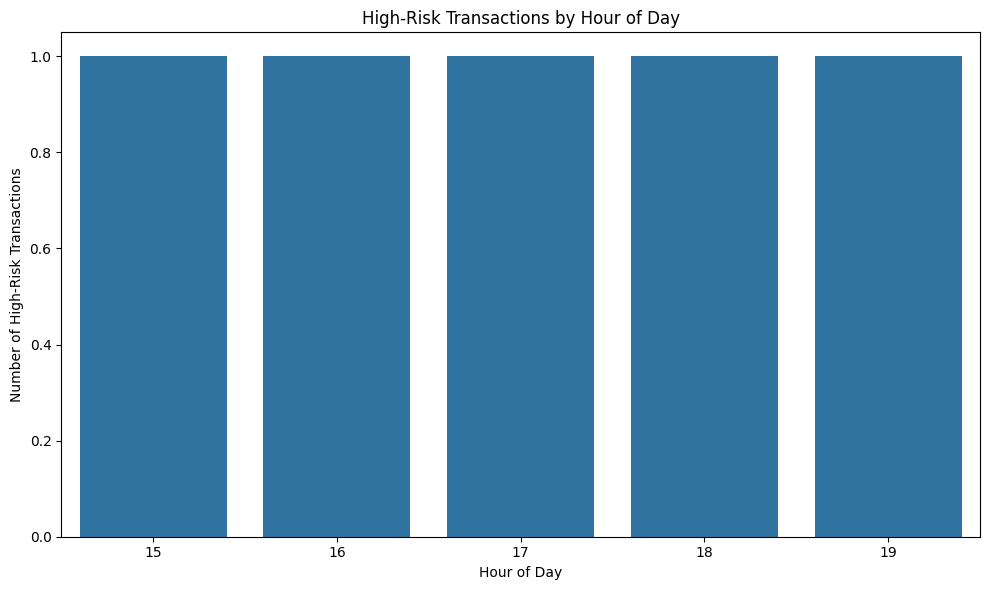

In [ ]:
# Visualize High-Risk Transactions by Hour of Day
if not high_risk_transactions.empty:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='hour_of_day', data=high_risk_transactions, order=sorted(high_risk_transactions['hour_of_day'].unique()))
    plt.title('High-Risk Transactions by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of High-Risk Transactions')
    plt.tight_layout()
    plt.show()
else:
    print("No high-risk transactions to visualize by hour of day.")

  product_name  Daily_sales  product_stock  expire_date  price seasons
0        phone           10             10            4   1000  summer
1         buds           15             15            6   2000  winter
2        dress           21             21            8   3000  summer
3      perfume           19             19            3   4000  winter
4        phone           16             16            5   5000  summer
5         food           28             28            6   6000  winter
6         buds           12             12            4   7000  summer
7        watch           11             13            7   8000  winter
8      perfume           14             10            5   9000  summer
9        phone           10             11            6  10000  winter
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_name   10 non-null 

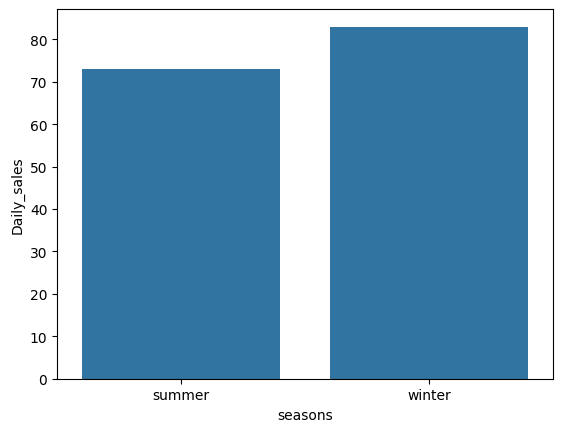

product_name
buds       27
dress      21
food       28
perfume    33
phone      36
watch      11
Name: Daily_sales, dtype: int64


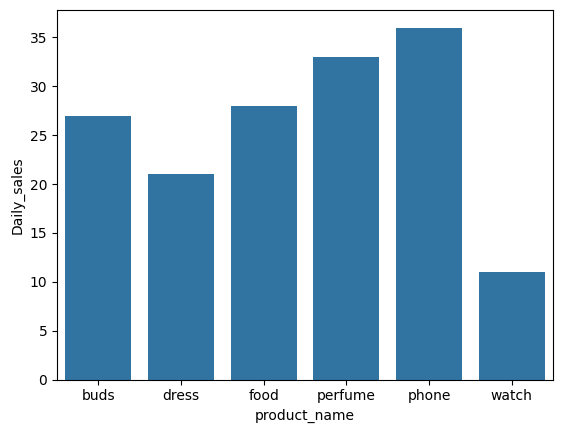

In [17]:
from itertools import product
#market analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.DataFrame({
    'product_name':['phone','buds','dress','perfume','phone','food','buds','watch','perfume','phone'],
    'Daily_sales':[10,15,21,19,16,28,12,11,14,10],
    'product_stock':[10,15,21,19,16,28,12,13,10,11],
    'expire_date':[4,6,8,3,5,6,4,7,5,6],
    'price':[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000],
    'seasons':['summer','winter','summer','winter','summer','winter','summer','winter','summer','winter']
})
print(data)
print(data.info())
#fast moving sales
fast_sales=data[data['Daily_sales']>10]
print(fast_sales)
season_wise_sales=data.groupby('seasons')['Daily_sales'].sum()
print(season_wise_sales)
sns.barplot(season_wise_sales)
plt.show()
product_wise_sales=data.groupby('product_name')['Daily_sales'].sum()
print(product_wise_sales)
sns.barplot(product_wise_sales)
plt.show()
